In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("cleaned_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk,productivity_index,work_intensity
0,1,Weekday,9.59,11.86,4,2,No,7.55,91.2,19.17,Low,9.509906,15.86
1,1,Weekend,7.38,10.33,4,1,No,6.69,82.0,29.70,Low,11.111111,14.33
2,1,Weekend,6.31,8.92,1,2,No,8.87,80.6,32.93,Low,12.773376,9.92
3,1,Weekday,8.34,10.70,4,1,Yes,8.13,70.0,45.47,Low,8.393285,14.70
4,1,Weekend,6.97,9.83,1,2,No,5.85,67.1,51.61,Low,9.626973,10.83


In [4]:
df.shape

(1800, 13)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
print(df.describe())

           user_id   work_hours  screen_time_hours  meetings_count  \
count  1800.000000  1800.000000        1800.000000     1800.000000   
mean     90.500000     6.515117           9.271406        1.941111   
std      51.975162     2.290521           2.409253        1.696178   
min       1.000000     3.000000           4.510000        0.000000   
25%      45.750000     4.430000           7.240000        1.000000   
50%      90.500000     6.445000           9.210000        2.000000   
75%     135.250000     8.510000          11.310000        3.000000   
max     180.000000    12.170000          15.700000       10.000000   

       breaks_taken  sleep_hours  task_completion_rate  burnout_score  \
count   1800.000000  1800.000000           1800.000000    1800.000000   
mean       3.028889     6.996467             72.308556      44.009978   
std        1.417844     1.061740             14.978647      23.881782   
min        1.000000     4.500000             40.000000       2.500000   
25% 

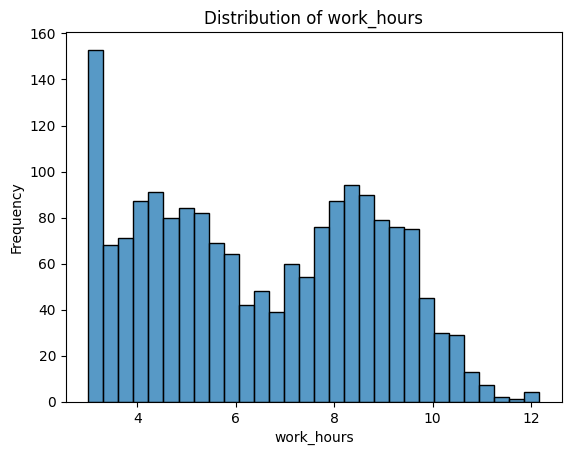

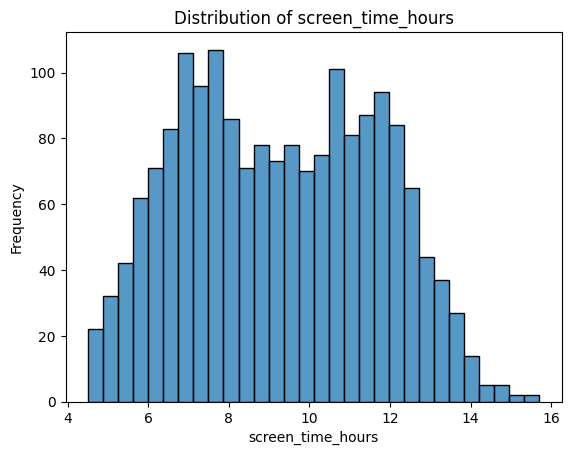

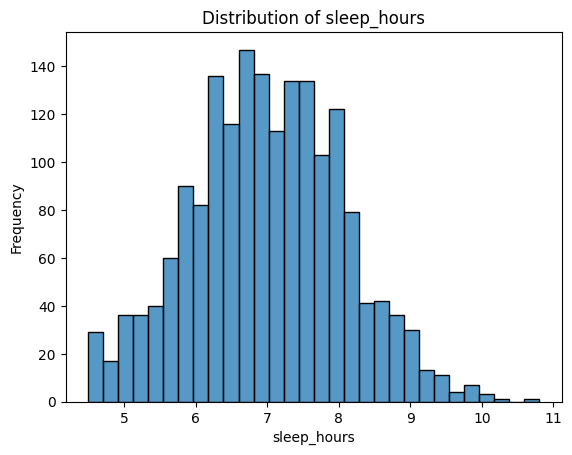

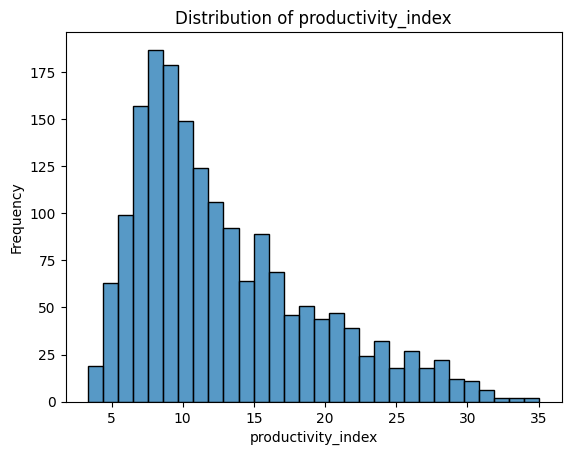

In [16]:
columns = ['work_hours', 'screen_time_hours', 'sleep_hours', 'productivity_index']

for col in columns:
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

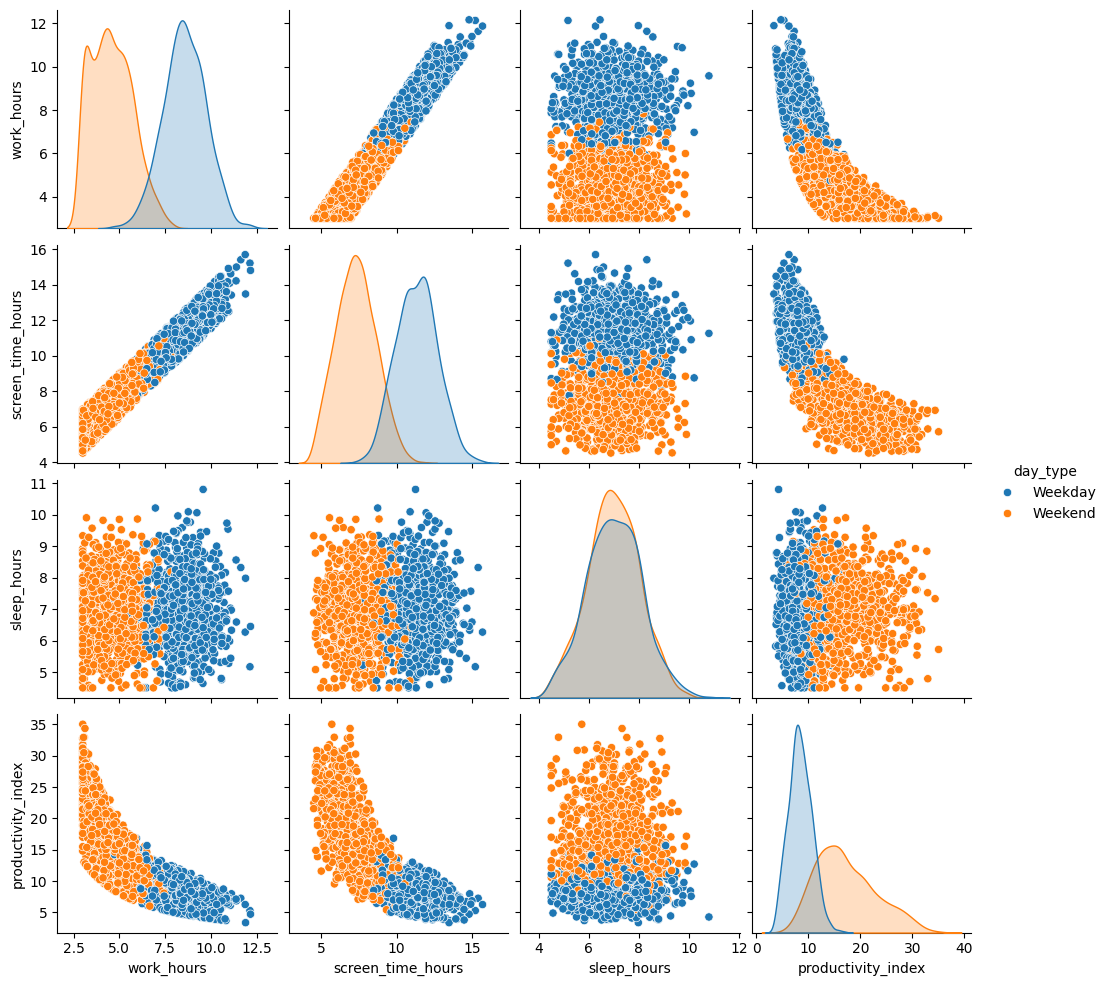

In [9]:
sns.pairplot(df, vars=['work_hours', 'screen_time_hours', 'sleep_hours', 'productivity_index'], hue='day_type')

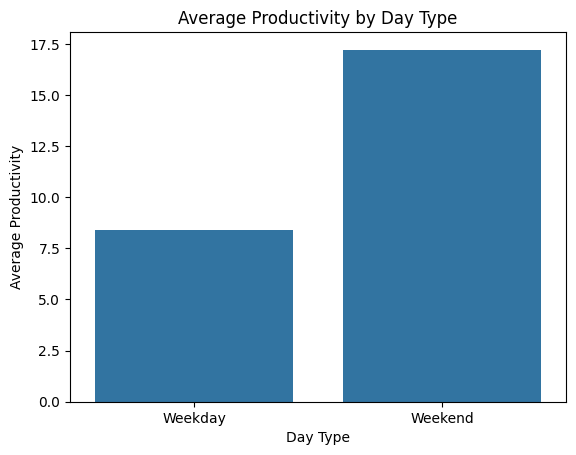

In [10]:
bar_data = df.groupby('day_type')['productivity_index'].mean().reset_index()
sns.barplot(x='day_type', y='productivity_index', data=bar_data)
plt.title('Average Productivity by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Average Productivity')
plt.show()

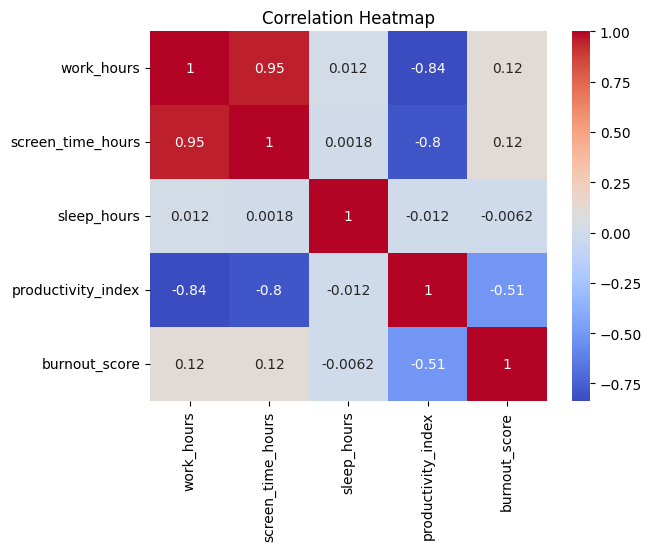

In [13]:
correlation = df[['work_hours', 'screen_time_hours', 'sleep_hours', 'productivity_index', 'burnout_score']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

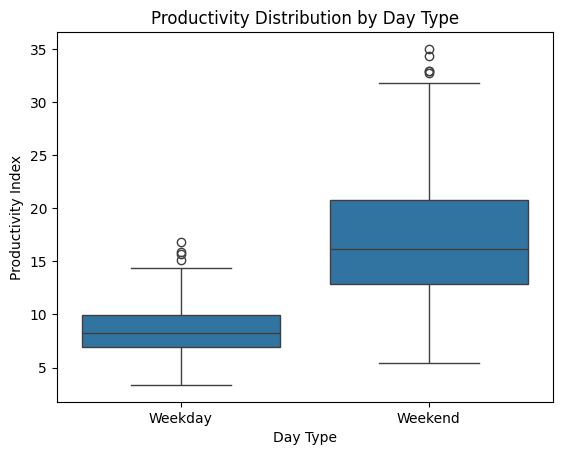

In [14]:
sns.boxplot(x='day_type', y='productivity_index', data=df)
plt.title('Productivity Distribution by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Productivity Index')
plt.show()

In [18]:
import pandas as pd
import sqlite3

df = pd.read_csv('cleaned_burnout_dataset.csv')  

conn = sqlite3.connect('my_database.db')

df.to_sql('employee_data', conn, if_exists='replace', index=False)

1800

In [19]:
query = """
SELECT day_type,
       AVG(productivity_index) AS avg_productivity
FROM employee_data
GROUP BY day_type;
"""

result = pd.read_sql(query, conn)
print(result)

  day_type  avg_productivity
0  Weekday          8.409799
1  Weekend         17.212172


In [20]:
query = """
SELECT user_id,
       SUM(breaks_taken) AS total_breaks
FROM employee_data
GROUP BY user_id
ORDER BY total_breaks DESC
LIMIT 5;
"""

result = pd.read_sql(query, conn)
print(result)

   user_id  total_breaks
0       24            43
1      103            42
2      168            40
3       50            39
4      165            38


In [21]:
query = """
SELECT day_type,
       AVG(after_hours_work) AS avg_after_hours
FROM employee_data
GROUP BY day_type;
"""

result = pd.read_sql(query, conn)
print(result)

  day_type  avg_after_hours
0  Weekday              0.0
1  Weekend              0.0
